In [14]:
import subprocess
subprocess.check_output(['nvidia-smi'])

b'Tue Apr 23 15:37:15 2024       \r\n+---------------------------------------------------------------------------------------+\r\n| NVIDIA-SMI 546.09                 Driver Version: 546.09       CUDA Version: 12.3     |\r\n|-----------------------------------------+----------------------+----------------------+\r\n| GPU  Name                     TCC/WDDM  | Bus-Id        Disp.A | Volatile Uncorr. ECC |\r\n| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |\r\n|                                         |                      |               MIG M. |\r\n|=========================================+======================+======================|\r\n|   0  NVIDIA GeForce MX350         WDDM  | 00000000:01:00.0 Off |                  N/A |\r\n| N/A   82C    P8              N/A / ERR! |    193MiB /  2048MiB |     54%      Default |\r\n|                                         |                      |                  N/A |\r\n+--------------------------------

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import os

In [16]:
import tensorflow as tf
from tensorflow import keras

In [17]:
train_path = "C:\\Users\\Aadhith\\Desktop\\Pulmonitor AI\\chest_xray\\train"
test_path = "C:\\Users\\Aadhith\\Desktop\\Pulmonitor AI\\chest_xray\\test"
val_path = "C:\\Users\\Aadhith\\Desktop\\Pulmonitor AI\\chest_xray\\val"

# Exploratory Data Analysis:

Number of images in class 0 (NORMAL): 1341
Number of images in class 1 (PNEUMONIA): 3875


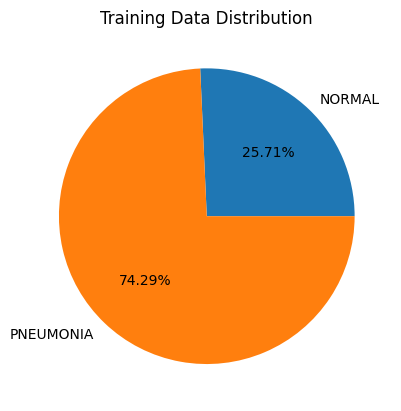

In [18]:
class_0_count = 0
class_1_count = 0

for label in os.listdir(train_path):
  if label == 'NORMAL':
    class_0_count += len(os.listdir(os.path.join(train_path, label)))
  elif label == 'PNEUMONIA':
    class_1_count += len(os.listdir(os.path.join(train_path, label)))

print("Number of images in class 0 (NORMAL):", class_0_count)
print("Number of images in class 1 (PNEUMONIA):", class_1_count)

data = [class_0_count, class_1_count]
labels = ['NORMAL', 'PNEUMONIA']

plt.pie(data, labels=labels, autopct='%1.2f%%')
plt.title('Training Data Distribution')
plt.show()

Number of images in class 0 (NORMAL): 234
Number of images in class 1 (PNEUMONIA): 390


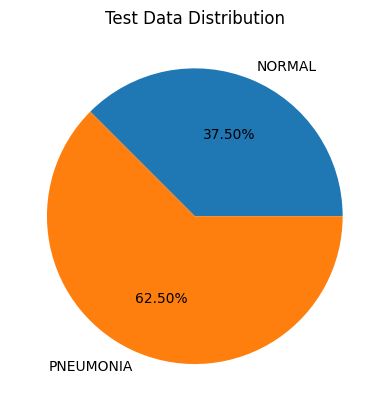

In [19]:
class_0_count_test = 0
class_1_count_test = 0

for label in os.listdir(test_path):
  if label == 'NORMAL':
    class_0_count_test += len(os.listdir(os.path.join(test_path, label)))
  elif label == 'PNEUMONIA':
    class_1_count_test += len(os.listdir(os.path.join(test_path, label)))

print("Number of images in class 0 (NORMAL):", class_0_count_test)
print("Number of images in class 1 (PNEUMONIA):", class_1_count_test)

data = [class_0_count_test, class_1_count_test]
labels = ['NORMAL', 'PNEUMONIA']

plt.pie(data, labels=labels, autopct='%1.2f%%')
plt.title('Test Data Distribution')
plt.show()

# Data Pre Processing:

In [20]:
from keras.preprocessing.image import ImageDataGenerator

In [21]:
hyper_dimension = 224
hyper_batch_size = 128
hyper_epochs = 100
hyper_channels = 3
hyper_mode = 'rgb'

In [22]:
train_datagen = ImageDataGenerator(rescale=1.0/255.0, 
                                   shear_range = 0.2,
                                   zoom_range = 0.2, 
                                   horizontal_flip = True)
test_datagen = ImageDataGenerator(rescale=1.0/255.0) 

In [23]:
train_generator = train_datagen.flow_from_directory(directory = train_path, 
                                                    target_size = (hyper_dimension, hyper_dimension),
                                                    batch_size = hyper_batch_size, 
                                                    color_mode = hyper_mode,
                                                    class_mode = 'binary',
                                                    seed = 42)

test_generator = test_datagen.flow_from_directory(directory = test_path, 
                                                 target_size = (hyper_dimension, hyper_dimension),
                                                 batch_size = hyper_batch_size, 
                                                 class_mode = 'binary',
                                                 color_mode = hyper_mode,
                                                 shuffle=False,
                                                 seed = 42)
test_generator.reset()

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [24]:
train_generator.class_indices

{'NORMAL': 0, 'PNEUMONIA': 1}

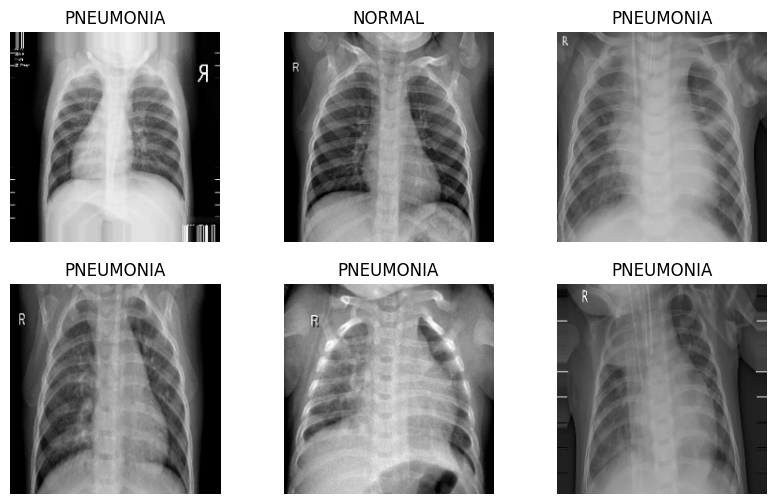

In [25]:
images, labels = train_generator.next()

class_labels = ['NORMAL', 'PNEUMONIA']
images = (images * 255).astype('uint8')

plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].astype('uint8'))
    plt.title(class_labels[int(labels[i])])
    plt.axis('off')

plt.show()

# ResNet:

## Training:

In [1]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the pre-trained layers
for layer in base_model.layers:
    layer.trainable = False




9406464/9406464 [==============================] - 10s 1us/step


In [18]:
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

# Create model
model = models.Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

In [19]:
model.compile(optimizer=optimizers.Adam(lr=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [21]:
history = model.fit(train_generator, epochs=100, validation_data=test_generator, callbacks=[early_stopping])

Epoch 1/100



41/41 [==============================] - 377s 9s/step - loss: 1.0591 - accuracy: 0.6618 - val_loss: 0.6901 - val_accuracy: 0.6250
Epoch 2/100
41/41 [==============================] - 321s 8s/step - loss: 0.6827 - accuracy: 0.7429 - val_loss: 0.6856 - val_accuracy: 0.6250
Epoch 3/100
41/41 [==============================] - 369s 9s/step - loss: 0.6738 - accuracy: 0.7429 - val_loss: 0.6815 - val_accuracy: 0.6250
Epoch 4/100
41/41 [==============================] - 327s 8s/step - loss: 0.7353 - accuracy: 0.7322 - val_loss: 0.6779 - val_accuracy: 0.6250


In [22]:
model.save('resnet_model1.keras')

## Testing:

In [36]:
from keras.models import load_model
resnet = load_model("C:\\Users\\Aadhith\\Desktop\\Pulmonitor AI\\resnet_model1.keras")
predictions = resnet.predict(test_generator)

5/5 [==============================] - 40s 7s/step


In [45]:
from sklearn.metrics import accuracy_score, roc_curve, confusion_matrix, roc_auc_score

In [19]:
np.unique(predictions)

array([0.50617486], dtype=float32)

Not working well

In [43]:
def create_charts(cnn, cnn_model):
    
    # train & validation loss
    train_loss = cnn_model.history['loss']
    val_loss = cnn_model.history['val_loss']
    
    # train & validation AUC
    train_auc_name = list(cnn_model.history.keys())[3]
    val_auc_name = list(cnn_model.history.keys())[1]
    train_auc = cnn_model.history[train_auc_name]
    val_auc = cnn_model.history[val_auc_name]
    
    # y_pred & y_true
    y_true = test_generator.classes
    Y_pred = cnn.predict_generator(test_generator, steps = len(test_generator))
    y_pred = (Y_pred > 0.5).T[0]
    y_pred_prob = Y_pred.T[0]
    
    fig = plt.figure(figsize=(13, 10))
    
    # PLOT 1: TRAIN VS. VALIDATION LOSS 
    plt.subplot(2,2,1)
    plt.title("Training vs. Validation Loss")
    plt.plot(train_loss, label='training loss')
    plt.plot(val_loss, label='validation loss')
    plt.xlabel("Number of Epochs", size=14)
    plt.legend()

    # PLOT 2: TRAIN VS. VALIDATION AUC
    plt.subplot(2,2,2)
    plt.title("Training vs. Validation AUC Score")
    plt.plot(train_auc, label='training auc')
    plt.plot(val_auc, label='validation auc')
    plt.xlabel("Number of Epochs", size=14)
    plt.legend()
    
    # PLOT 3: CONFUSION MATRIX
    plt.subplot(2,2,3)
    cm = confusion_matrix(y_true, y_pred)
    names = ['True Negatives', 'False Positives', 'False Negatives', 'True Positives']
    counts = ['{0:0.0f}'.format(value) for value in cm.flatten()]
    percentages = ['{0:.2%}'.format(value) for value in cm.flatten()/np.sum(cm)]
    labels = [f'{v1}\n{v2}' for v1, v2 in zip(names, percentages)]
    labels = np.asarray(labels).reshape(2,2)
    ticklabels = ['Normal', 'Pneumonia']

    # Create confusion matrix as heatmap
    sns.set(font_scale = 1.4)
    ax = sns.heatmap(cm, annot=labels, fmt='', cmap='Oranges', xticklabels=ticklabels, yticklabels=ticklabels )
    plt.xticks(size=12)
    plt.yticks(size=12)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted", size=14)
    plt.ylabel("Actual", size=14) 
    
    ## PLOT 4: ROC CURVE
    plt.subplot(2,2,4)
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    auc = roc_auc_score(y_true, y_pred_prob)
    plt.title('ROC Curve')
    plt.plot([0, 1], [0, 1], 'k--', label = "Random (AUC = 50%)")
    plt.plot(fpr, tpr, label='Model (AUC = {:.2f}%)'.format(auc*100))
    plt.xlabel('False Positive Rate', size=14)
    plt.ylabel('True Positive Rate', size=14)
    plt.legend(loc='best')
    plt.tight_layout()
    
    # Summary Statistics
    TN, FP, FN, TP = cm.ravel()
    accuracy = (TP + TN) / np.sum(cm)
    precision = TP / (TP+FP)
    recall =  TP / (TP+FN)
    specificity = TN / (TN+FP)
    f1 = 2*precision*recall / (precision + recall)
    stats_summary = '[Summary Statistics]\nAccuracy = {:.2%} | Precision = {:.2%} | Recall = {:.2%} | Specificity = {:.2%} | F1 Score = {:.2%}'.format(accuracy, precision, recall, specificity, f1)
    print(stats_summary)

In [ ]:
y_true = test_generator.classes
Y_pred = resnet.predict_generator(test_generator, steps = len(test_generator))
y_pred = (Y_pred > 0.5).T[0]
y_pred_prob = Y_pred.T[0]

In [ ]:
y_true_new = y_true == 1
y_true_new = np.logical_not(y_true_new)
y_true_new

In [ ]:
create_charts(resnet, history)

4/4 [==============================] - 8s 2s/step


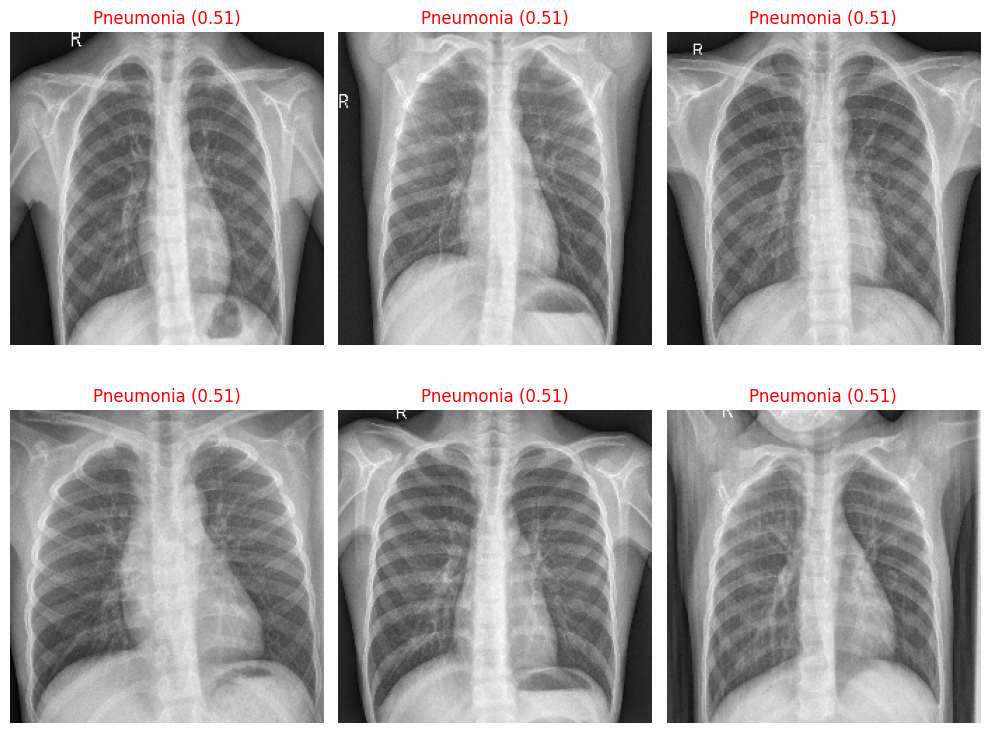

In [25]:
plt.figure(figsize=(10, 8))

x, y_true = next(test_generator)
predictions = resnet.predict(x)

for j in range(6):  # Modify to display in a 3x2 grid
    image = x[j]
    plt.subplot(2, 3, j + 1)  # Adjust subplot position
    plt.imshow(image)

    # Get the predicted class and its probability
    predicted_class = 'Pneumonia' if predictions[j] > 0.5 else 'Normal'
    probability = float(predictions[j]) if predictions[j] > 0.5 else float(1 - predictions[j])

    # Green if prediction is correct
    color = 'green' if (predicted_class == 'Pneumonia' and y_true[j] == 1) or (predicted_class == 'Normal' and y_true[j] == 0) else 'red'

    # Display the class and probability
    plt.title(f'{predicted_class} ({probability:.2f})', color=color)
    plt.axis('off')

# Adjust layout
plt.tight_layout()
plt.show()

# VGG16:

## Training:

In [13]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers (optional - experiment with unfreezing)
for layer in base_model.layers:
  layer.trainable = False

In [14]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping

x = layers.Flatten()(base_model.output)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

# Create model
model = models.Model(inputs=base_model.input, outputs=output)

early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

In [15]:
model.compile(optimizer=optimizers.Adam(lr=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [16]:
history = model.fit(train_generator, epochs=100, validation_data=test_generator, callbacks=[early_stopping])

Epoch 1/100



41/41 [==============================] - 2632s 65s/step - loss: 0.5512 - accuracy: 0.8416 - val_loss: 0.3070 - val_accuracy: 0.8766
Epoch 2/100
41/41 [==============================] - 961s 23s/step - loss: 0.1799 - accuracy: 0.9216 - val_loss: 0.3219 - val_accuracy: 0.8942
Epoch 3/100
41/41 [==============================] - 936s 23s/step - loss: 0.1562 - accuracy: 0.9350 - val_loss: 0.2698 - val_accuracy: 0.9135
Epoch 4/100
41/41 [==============================] - 1163s 28s/step - loss: 0.1468 - accuracy: 0.9467 - val_loss: 0.3000 - val_accuracy: 0.9038
Epoch 5/100
41/41 [==============================] - 1143s 28s/step - loss: 0.1310 - accuracy: 0.9496 - val_loss: 0.2972 - val_accuracy: 0.9054
Epoch 6/100
41/41 [==============================] - 964s 23s/step - loss: 0.1296 - accuracy: 0.9532 - val_loss: 0.2604 - val_accuracy: 0.9119


In [24]:
model.save("vgg16_model1.keras")

## Testing:

In [34]:
vgg16 = load_model("C:\\Users\\Aadhith\\Desktop\\Pulmonitor AI\\vgg16_model1.keras")
predictions = vgg16.predict(test_generator)

5/5 [==============================] - 95s 18s/step


In [35]:
np.unique(predictions)

array([0.02392309, 0.02502959, 0.02630674, 0.03131774, 0.03205691,
       0.03384544, 0.03398532, 0.0349883 , 0.03802441, 0.04118191,
       0.04668322, 0.05154562, 0.05168534, 0.05179221, 0.0522644 ,
       0.05275495, 0.05403364, 0.05517501, 0.05555456, 0.05690924,
       0.05934844, 0.06014901, 0.06030756, 0.06042345, 0.0613581 ,
       0.06137821, 0.06150109, 0.06234765, 0.06480069, 0.06559744,
       0.06561633, 0.06702363, 0.06855151, 0.06936302, 0.06971604,
       0.07022815, 0.07063653, 0.07079518, 0.07220798, 0.072402  ,
       0.07244535, 0.07324856, 0.07359873, 0.0748821 , 0.07583756,
       0.07648128, 0.07657671, 0.07947651, 0.07963423, 0.08104536,
       0.08677899, 0.0868379 , 0.08712565, 0.08742247, 0.08828956,
       0.08920913, 0.09100241, 0.09127415, 0.09224185, 0.09233946,
       0.09346725, 0.09470808, 0.09496954, 0.09584534, 0.09723634,
       0.09783276, 0.098466  , 0.09896959, 0.09907874, 0.10058223,
       0.1021217 , 0.10281591, 0.10289416, 0.10306609, 0.10322

In [36]:
y_true = test_generator.classes
Y_pred = vgg16.predict_generator(test_generator, steps = len(test_generator))
y_pred = (Y_pred > 0.5).T[0]
y_pred_prob = Y_pred.T[0]

C:\Users\Aadhith\AppData\Local\Temp\ipykernel_2316\2152784817.py:2: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  Y_pred = vgg16.predict_generator(test_generator, steps = len(test_generator))


In [37]:
y_true_new = y_true == 1
y_true_new = np.logical_not(y_true_new)
y_true_new

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

C:\Users\Aadhith\AppData\Local\Temp\ipykernel_2316\1586901572.py:15: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  Y_pred = cnn.predict_generator(test_generator, steps = len(test_generator))


[Summary Statistics]
Accuracy = 91.35% | Precision = 90.00% | Recall = 96.92% | Specificity = 82.05% | F1 Score = 93.33%


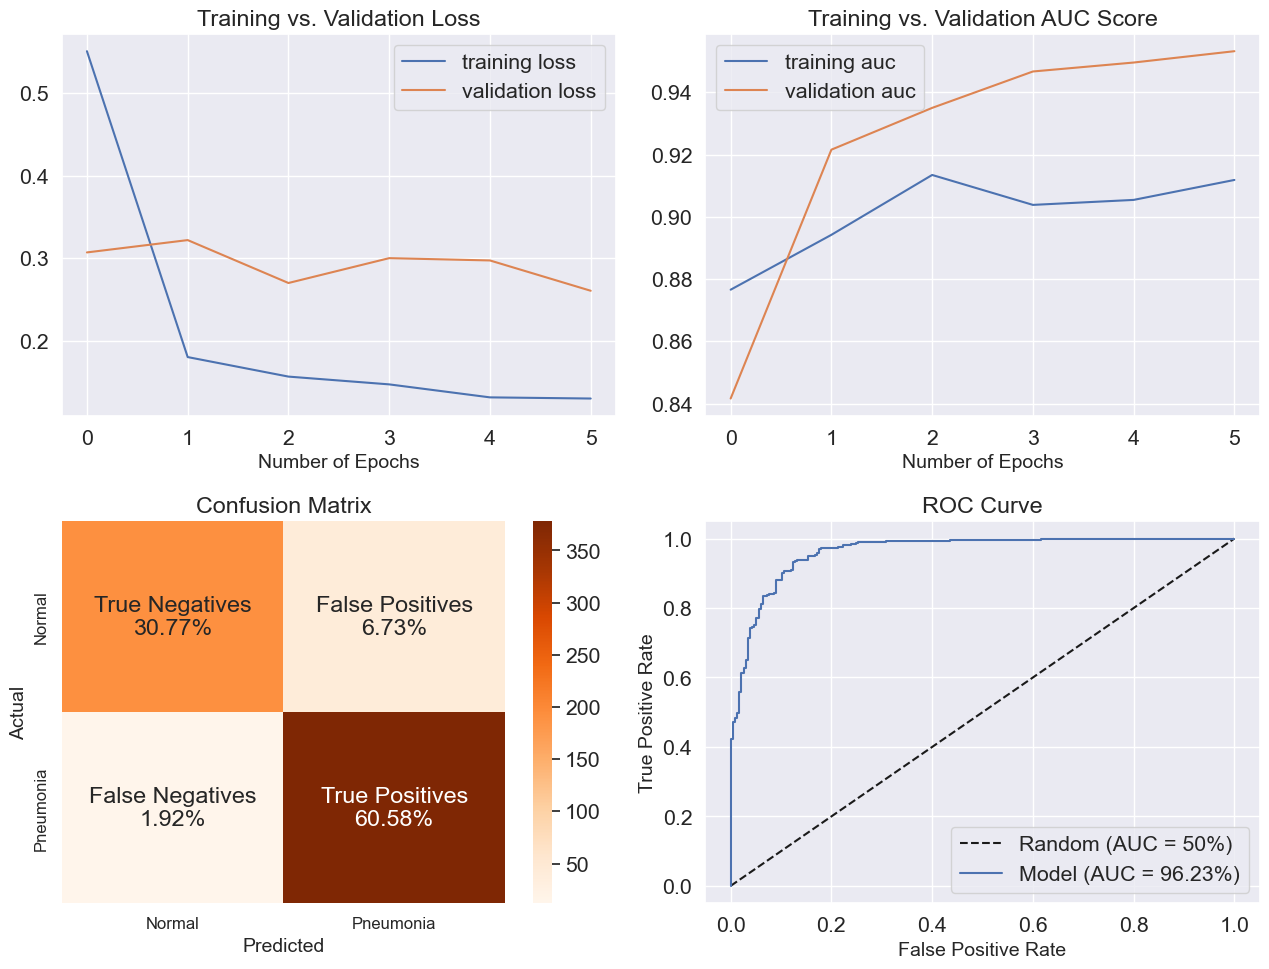

In [38]:
create_charts(vgg16, history)

4/4 [==============================] - 16s 4s/step


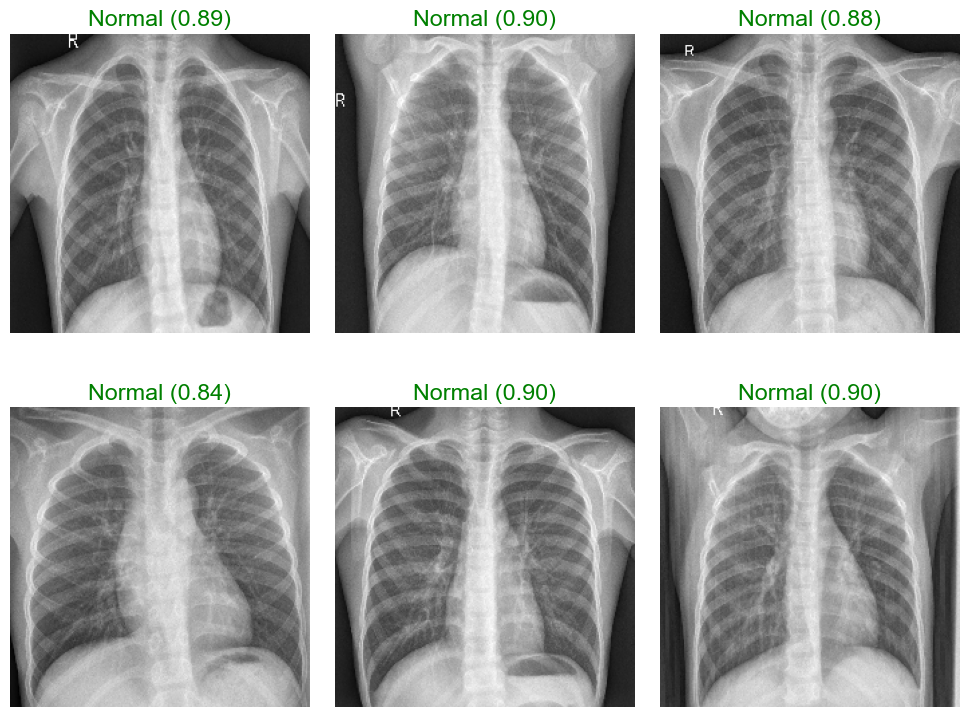

In [30]:
plt.figure(figsize=(10, 8))

x, y_true = next(test_generator)
predictions = vgg16.predict(x)

for j in range(6):  # Modify to display in a 3x2 grid
    image = x[j]
    plt.subplot(2, 3, j + 1)  # Adjust subplot position
    plt.imshow(image)

    # Get the predicted class and its probability
    predicted_class = 'Pneumonia' if predictions[j] > 0.5 else 'Normal'
    probability = float(predictions[j]) if predictions[j] > 0.5 else float(1 - predictions[j])

    # Green if prediction is correct
    color = 'green' if (predicted_class == 'Pneumonia' and y_true[j] == 1) or (predicted_class == 'Normal' and y_true[j] == 0) else 'red'

    # Display the class and probability
    plt.title(f'{predicted_class} ({probability:.2f})', color=color)
    plt.axis('off')

# Adjust layout
plt.tight_layout()
plt.show()

# MobileNetV2:

## Training:

In [26]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

In [28]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

In [52]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_2[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']        

In [30]:
history = model.fit(train_generator, epochs=100, validation_data=test_generator, callbacks=[early_stopping])

Epoch 1/100



41/41 [==============================] - 158s 4s/step - loss: 0.2849 - accuracy: 0.8829 - val_loss: 0.3124 - val_accuracy: 0.8686
Epoch 2/100
41/41 [==============================] - 143s 3s/step - loss: 0.1565 - accuracy: 0.9331 - val_loss: 0.2677 - val_accuracy: 0.8814
Epoch 3/100
41/41 [==============================] - 142s 3s/step - loss: 0.1286 - accuracy: 0.9486 - val_loss: 0.2997 - val_accuracy: 0.8878
Epoch 4/100
41/41 [==============================] - 142s 3s/step - loss: 0.1279 - accuracy: 0.9484 - val_loss: 0.2661 - val_accuracy: 0.8766
Epoch 5/100
41/41 [==============================] - 143s 3s/step - loss: 0.1166 - accuracy: 0.9567 - val_loss: 0.2771 - val_accuracy: 0.8862
Epoch 6/100
41/41 [==============================] - 152s 4s/step - loss: 0.1152 - accuracy: 0.9574 - val_loss: 0.3325 - val_accuracy: 0.8718


In [33]:
model.save("mobilenetv2_model1.keras")

## Testing:

In [54]:
best_model = early_stopping.model
best_model.save("mobilenetv2_model2.keras")

c:\Users\Aadhith\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [55]:
mobilenetv2 = load_model("C:\\Users\\Aadhith\\Desktop\\Pulmonitor AI\\mobilenetv2_model2.keras")
predictions = mobilenetv2.predict(test_generator)

5/5 [==============================] - 11s 2s/step


In [56]:
np.unique(predictions)

array([0.00325466, 0.00357336, 0.00371671, 0.00429964, 0.00480523,
       0.00489183, 0.00506123, 0.0053508 , 0.0059309 , 0.00641696,
       0.00767203, 0.00943842, 0.01022594, 0.01023248, 0.01058445,
       0.01085021, 0.01088259, 0.01188785, 0.01215602, 0.01224277,
       0.01300298, 0.01500826, 0.0150159 , 0.01553487, 0.01558753,
       0.01625048, 0.01629496, 0.01640307, 0.01642425, 0.01717494,
       0.01721092, 0.0174396 , 0.01802742, 0.01831819, 0.01851851,
       0.01905094, 0.02087708, 0.02103685, 0.02121303, 0.02156544,
       0.02287957, 0.02302746, 0.02335329, 0.02405198, 0.02432362,
       0.02530744, 0.02544218, 0.02590315, 0.02722602, 0.02798559,
       0.02853364, 0.02853502, 0.02961433, 0.0300309 , 0.03072175,
       0.03327804, 0.03525322, 0.03849299, 0.03856771, 0.03896238,
       0.0405907 , 0.0412472 , 0.04255042, 0.0431335 , 0.04485002,
       0.04488698, 0.04494653, 0.04495366, 0.04644087, 0.04668839,
       0.04767458, 0.04936035, 0.05079835, 0.05085773, 0.05169

In [57]:
y_true = test_generator.classes
Y_pred = mobilenetv2.predict_generator(test_generator, steps = len(test_generator))
y_pred = (Y_pred > 0.5).T[0]
y_pred_prob = Y_pred.T[0]

C:\Users\Aadhith\AppData\Local\Temp\ipykernel_4296\3051069816.py:2: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  Y_pred = mobilenetv2.predict_generator(test_generator, steps = len(test_generator))


In [58]:
y_true_new = y_true == 1
y_true_new = np.logical_not(y_true_new)

C:\Users\Aadhith\AppData\Local\Temp\ipykernel_4296\1586901572.py:15: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  Y_pred = cnn.predict_generator(test_generator, steps = len(test_generator))


[Summary Statistics]
Accuracy = 88.78% | Precision = 85.56% | Recall = 98.72% | Specificity = 72.22% | F1 Score = 91.67%


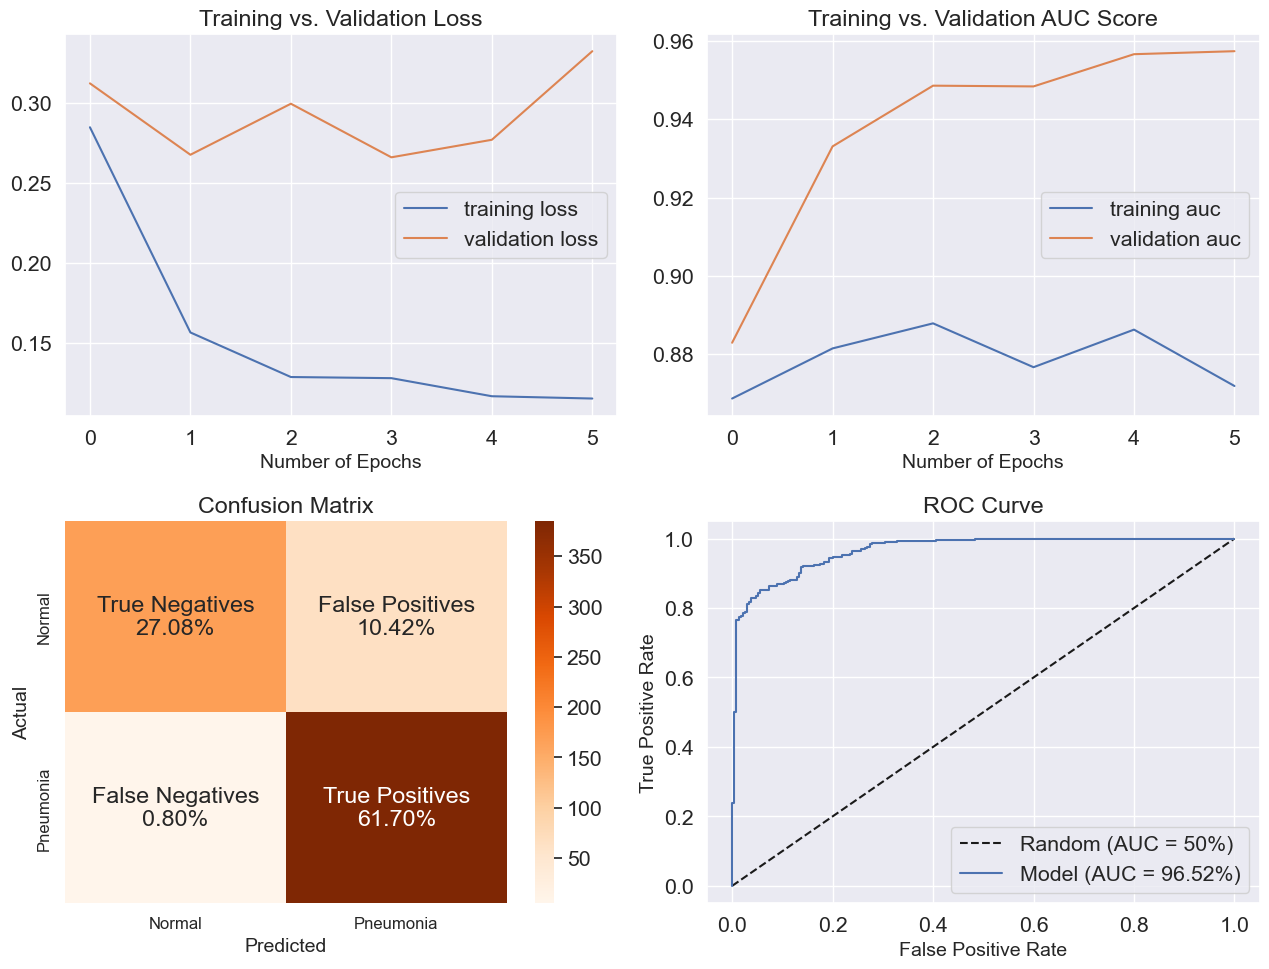

In [59]:
create_charts(mobilenetv2, history)

# InceptionV3:

## Training:

In [53]:
from tensorflow.keras.applications import InceptionV3

base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

87910968/87910968 [==============================] - 94s 1us/step


In [64]:
x = layers.Flatten()(base_model.output)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

In [65]:
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 111, 111, 32)         864       ['input_4[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 111, 111, 32)         96        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 111, 111, 32)         0         ['batch_normalization[0]

In [66]:
history = model.fit(train_generator, epochs=100, validation_data=test_generator, callbacks=[early_stopping])

Epoch 1/100
41/41 [==============================] - 315s 7s/step - loss: 2.6239 - accuracy: 0.8006 - val_loss: 0.5937 - val_accuracy: 0.7404
Epoch 2/100
41/41 [==============================] - 242s 6s/step - loss: 0.2527 - accuracy: 0.8953 - val_loss: 0.4722 - val_accuracy: 0.8253
Epoch 3/100
41/41 [==============================] - 242s 6s/step - loss: 0.2205 - accuracy: 0.9218 - val_loss: 0.4809 - val_accuracy: 0.8285
Epoch 4/100
41/41 [==============================] - 240s 6s/step - loss: 0.1924 - accuracy: 0.9283 - val_loss: 0.4649 - val_accuracy: 0.8269
Epoch 5/100
41/41 [==============================] - 260s 6s/step - loss: 0.1888 - accuracy: 0.9335 - val_loss: 0.4338 - val_accuracy: 0.8526
Epoch 6/100
41/41 [==============================] - 1060s 26s/step - loss: 0.1732 - accuracy: 0.9388 - val_loss: 0.4267 - val_accuracy: 0.8413
Epoch 7/100
41/41 [==============================] - 227s 6s/step - loss: 0.1719 - accuracy: 0.9388 - val_loss: 0.3753 - val_accuracy: 0.8574
Epoc

In [67]:
model.save("inceptionv3_model1.keras")

c:\Users\Aadhith\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Testing:

In [68]:
best_model = early_stopping.model
best_model.save("inceptionv3_model2.keras")

In [69]:
inceptionv3 = load_model("C:\\Users\\Aadhith\\Desktop\\Pulmonitor AI\\inceptionv3_model2.keras")
predictions = inceptionv3.predict(test_generator)

5/5 [==============================] - 28s 4s/step


In [70]:
np.unique(predictions)

array([0.0027537 , 0.01063559, 0.01260622, 0.01339598, 0.014628  ,
       0.01512052, 0.01867463, 0.01886526, 0.02026657, 0.02118225,
       0.02364513, 0.0238683 , 0.03091214, 0.03618796, 0.03682362,
       0.03682701, 0.03897419, 0.04099669, 0.04550029, 0.04648868,
       0.04708406, 0.04731511, 0.04926566, 0.04947243, 0.05378282,
       0.05411047, 0.05486318, 0.05496906, 0.05783724, 0.05808016,
       0.06102984, 0.06259084, 0.06268041, 0.06574272, 0.06698263,
       0.07121401, 0.07320666, 0.07481752, 0.07574452, 0.07736764,
       0.08007445, 0.08289414, 0.08405374, 0.08448047, 0.08457443,
       0.09033245, 0.09077096, 0.09337235, 0.09438571, 0.09586691,
       0.09675349, 0.09707355, 0.09768242, 0.1026648 , 0.10307721,
       0.10423701, 0.10446693, 0.10702688, 0.10795057, 0.10929579,
       0.11208796, 0.11234019, 0.1138491 , 0.11605231, 0.11958507,
       0.12067316, 0.12427069, 0.124464  , 0.12495546, 0.1261604 ,
       0.12671544, 0.13655478, 0.13797465, 0.14022508, 0.14598

In [72]:
y_true = test_generator.classes
Y_pred = inceptionv3.predict_generator(test_generator, steps = len(test_generator))
y_pred = (Y_pred > 0.5).T[0]
y_pred_prob = Y_pred.T[0]
y_true_new = y_true == 1
y_true_new = np.logical_not(y_true_new)

C:\Users\Aadhith\AppData\Local\Temp\ipykernel_4296\274790977.py:2: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  Y_pred = inceptionv3.predict_generator(test_generator, steps = len(test_generator))


C:\Users\Aadhith\AppData\Local\Temp\ipykernel_4296\1586901572.py:15: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  Y_pred = cnn.predict_generator(test_generator, steps = len(test_generator))


[Summary Statistics]
Accuracy = 87.02% | Precision = 84.11% | Recall = 97.69% | Specificity = 69.23% | F1 Score = 90.39%


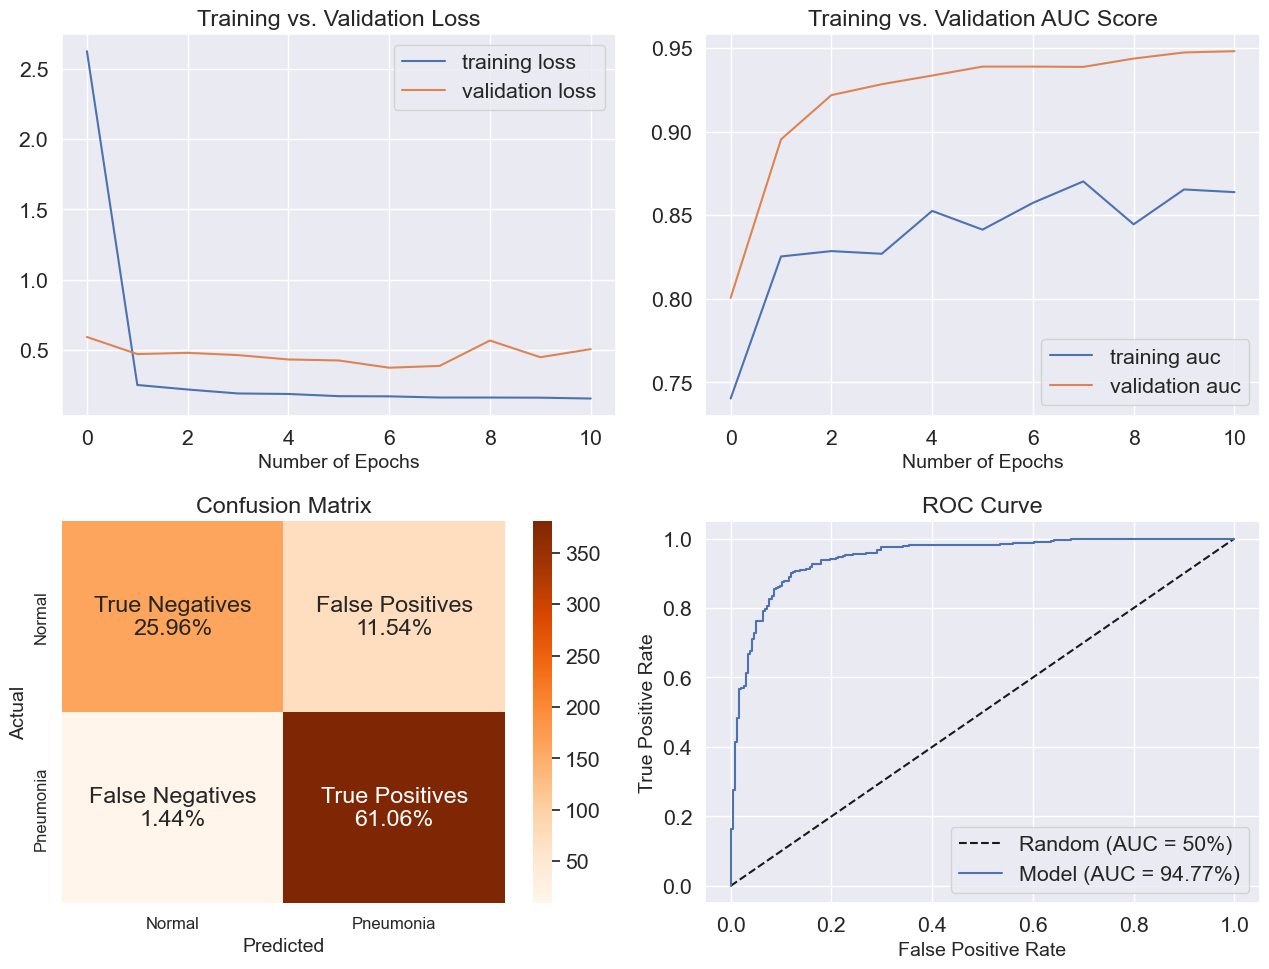

In [73]:
create_charts(inceptionv3, history)